--- STATUS AWAL ---
Total Populasi (N) : 1000
Probabilitas +1    : 0.7500
Probabilitas -1    : 0.2500
M Awal (Teoritis)  : 0.5000

--- SETELAH ASSIGN SPIN RANDOM ---
Aktual N_up   : 750
Aktual N_down : 250
M Aktual      : 0.5000



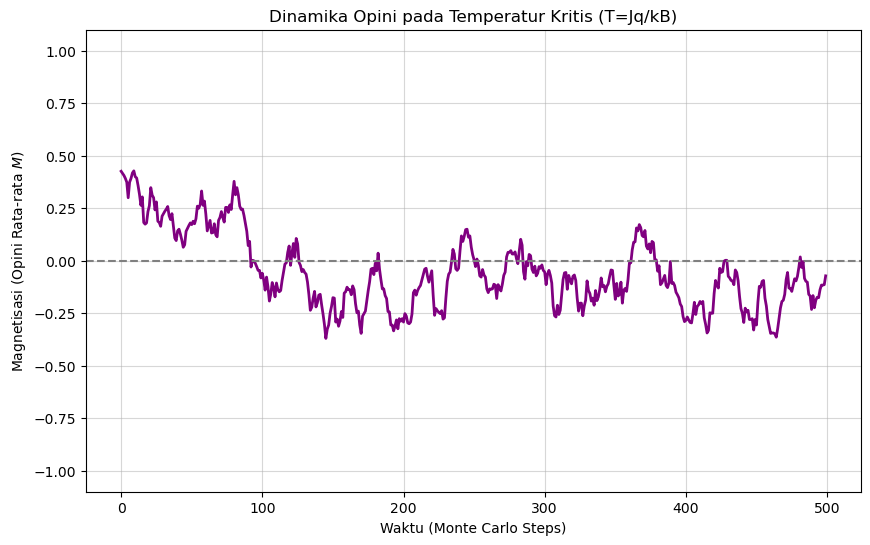

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_glauber_with_data(awal_N_up, awal_N_down, T, h, J, q, steps):
# 1. INISIALISASI DARI DATA AWAL
    N = awal_N_up + awal_N_down
    
# Menghitung probabilitas opini + dan -
    P_up = awal_N_up / N
    P_down = awal_N_down / N
    
# Menghitung Magnetisasi awal secara teoritis dari data
    M_awal = (awal_N_up - awal_N_down) / N
    
    print(f"--- STATUS AWAL ---")
    print(f"Total Populasi (N) : {N}")
    print(f"Probabilitas +1    : {P_up:.4f}")
    print(f"Probabilitas -1    : {P_down:.4f}")
    print(f"M Awal (Teoritis)  : {M_awal:.4f}\n")
    
# Assign spin secara acak berdasarkan probabilitas P_up dan P_down
    spins = np.array([1] * awal_N_up + [-1] * awal_N_down)
    np.random.shuffle(spins)

    N_up = awal_N_up
    N_down = awal_N_down
    
# Hitung jumlah aktual setelah di-assign (bisa sedikit berfluktuasi karena efek randomisasi probabilitas)
    N_up = np.sum(spins == 1)
    N_down = np.sum(spins == -1)
    
    print(f"--- SETELAH ASSIGN SPIN RANDOM ---")
    print(f"Aktual N_up   : {N_up}")
    print(f"Aktual N_down : {N_down}")
    print(f"M Aktual      : {(N_up - N_down) / N:.4f}\n")

# 2. SIMULASI GLAUBER + MEAN-FIELD
    magnetization_history = []
    kB = 0.6 
    
    for step in range(steps):
        # Inner loop: N kali percobaan per 1 Monte Carlo Step
        for _ in range(N):
            M = (N_up - N_down) / N
            h_eff = h + J * q * M
            
            i = np.random.randint(0, N)
            sigma_i = spins[i]
            
            delta_E = 2 * sigma_i * h_eff
            
            exp_term = np.exp(np.clip(delta_E / (kB * T), -100, 100))
            P_flip = 1.0 / (1.0 + exp_term)
            
            r = np.random.rand()
            if r < P_flip:
                spins[i] = -sigma_i
                
                if spins[i] == 1:
                    N_up += 1
                    N_down -= 1
                else:
                    N_up -= 1
                    N_down += 1
                    
        magnetization_history.append((N_up - N_down) / N)
        
    return magnetization_history

# Parameter & Eksekusi Simulasi
# Data Awal Opini (Misal: 750 orang setuju, 250 tidak setuju)
Data_N_up = 750
Data_N_down = 250

# Parameter Dinamika
External_field = 0.0 
J_coupling = 0.3     
q_neighbors = 4.0    
Time_steps = 500
Temperature = 2.0

# Jalankan simulasi
M_history = simulate_glauber_with_data(
    awal_N_up=Data_N_up, awal_N_down=Data_N_down, T=Temperature,
    h=External_field, J=J_coupling, 
    q=q_neighbors, steps=Time_steps
)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(M_history, color='purple', linewidth=2)
plt.title("Dinamika Opini pada Temperatur Kritis (T=Jq/kB)")
plt.xlabel("Waktu (Monte Carlo Steps)")
plt.ylabel("Magnetisasi (Opini Rata-rata $M$)")
plt.ylim(-1.1, 1.1)
plt.axhline(0, color='gray', linestyle='--')
plt.grid(True, alpha=0.5)
plt.show()

--- STATUS AWAL ---
Total Populasi (N) : 1000
Probabilitas +1    : 0.7500
Probabilitas -1    : 0.2500
M Awal (Teoritis)  : 0.5000

--- SETELAH ASSIGN SPIN RANDOM ---
Aktual N_up   : 750
Aktual N_down : 250
M Aktual      : 0.5000



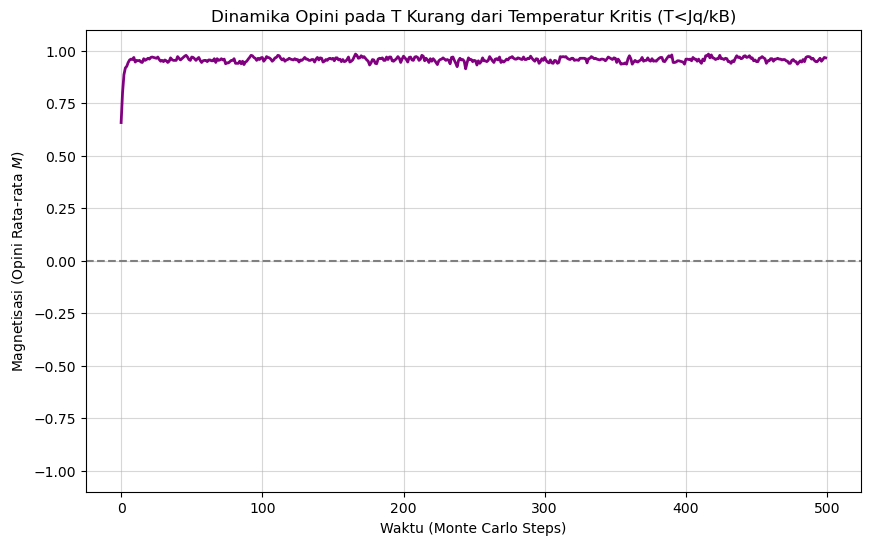

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_glauber_with_data(awal_N_up, awal_N_down, T, h, J, q, steps):
# 1. INISIALISASI DARI DATA AWAL
    N = awal_N_up + awal_N_down
    
# Menghitung probabilitas opini + dan -
    P_up = awal_N_up / N
    P_down = awal_N_down / N
    
# Menghitung Magnetisasi awal secara teoritis dari data
    M_awal = (awal_N_up - awal_N_down) / N
    
    print(f"--- STATUS AWAL ---")
    print(f"Total Populasi (N) : {N}")
    print(f"Probabilitas +1    : {P_up:.4f}")
    print(f"Probabilitas -1    : {P_down:.4f}")
    print(f"M Awal (Teoritis)  : {M_awal:.4f}\n")
    
# Assign spin secara acak berdasarkan probabilitas P_up dan P_down
    spins = np.array([1] * awal_N_up + [-1] * awal_N_down)
    np.random.shuffle(spins)

    N_up = awal_N_up
    N_down = awal_N_down
    
# Hitung jumlah aktual setelah di-assign (bisa sedikit berfluktuasi karena efek randomisasi probabilitas)
    N_up = np.sum(spins == 1)
    N_down = np.sum(spins == -1)
    
    print(f"--- SETELAH ASSIGN SPIN RANDOM ---")
    print(f"Aktual N_up   : {N_up}")
    print(f"Aktual N_down : {N_down}")
    print(f"M Aktual      : {(N_up - N_down) / N:.4f}\n")

# 2. SIMULASI GLAUBER + MEAN-FIELD
    magnetization_history = []
    kB = 0.6 
    
    for step in range(steps):
        # Inner loop: N kali percobaan per 1 Monte Carlo Step
        for _ in range(N):
            M = (N_up - N_down) / N
            h_eff = h + J * q * M
            
            i = np.random.randint(0, N)
            sigma_i = spins[i]
            
            delta_E = 2 * sigma_i * h_eff
            
            exp_term = np.exp(np.clip(delta_E / (kB * T), -100, 100))
            P_flip = 1.0 / (1.0 + exp_term)
            
            r = np.random.rand()
            if r < P_flip:
                spins[i] = -sigma_i
                
                if spins[i] == 1:
                    N_up += 1
                    N_down -= 1
                else:
                    N_up -= 1
                    N_down += 1
                    
        magnetization_history.append((N_up - N_down) / N)
        
    return magnetization_history

# Parameter & Eksekusi Simulasi
# Data Awal Opini (Misal: 750 orang setuju, 250 tidak setuju)
Data_N_up = 750
Data_N_down = 250

# Parameter Dinamika
External_field = 0.0 
J_coupling = 0.3     
q_neighbors = 4.0    
Time_steps = 500
Temperature = 1.0

# Jalankan simulasi
M_history = simulate_glauber_with_data(
    awal_N_up=Data_N_up, awal_N_down=Data_N_down, T=Temperature,
    h=External_field, J=J_coupling, 
    q=q_neighbors, steps=Time_steps
)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(M_history, color='purple', linewidth=2)
plt.title("Dinamika Opini pada T Kurang dari Temperatur Kritis (T<Jq/kB)")
plt.xlabel("Waktu (Monte Carlo Steps)")
plt.ylabel("Magnetisasi (Opini Rata-rata $M$)")
plt.ylim(-1.1, 1.1)
plt.axhline(0, color='gray', linestyle='--')
plt.grid(True, alpha=0.5)
plt.show()

--- STATUS AWAL ---
Total Populasi (N) : 1000
Probabilitas +1    : 0.7500
Probabilitas -1    : 0.2500
M Awal (Teoritis)  : 0.5000

--- SETELAH ASSIGN SPIN RANDOM ---
Aktual N_up   : 750
Aktual N_down : 250
M Aktual      : 0.5000



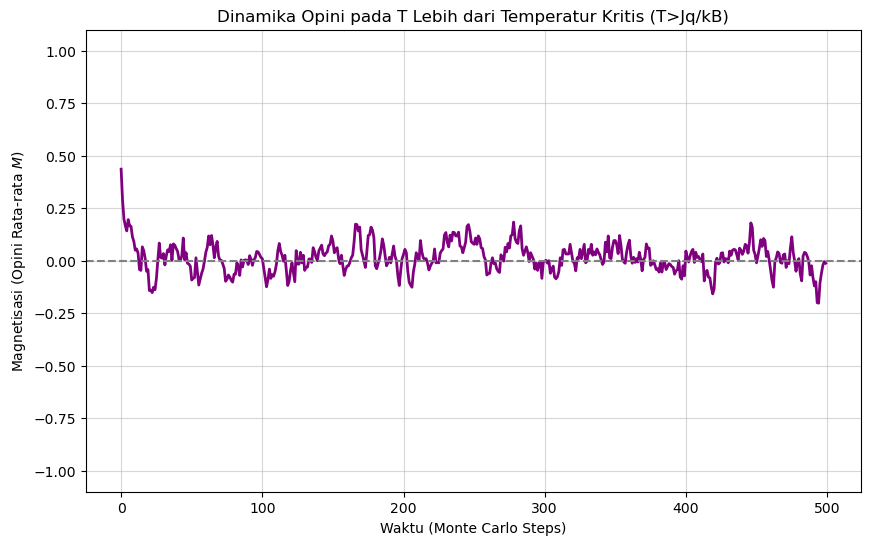

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_glauber_with_data(awal_N_up, awal_N_down, T, h, J, q, steps):
# 1. INISIALISASI DARI DATA AWAL
    N = awal_N_up + awal_N_down
    
# Menghitung probabilitas opini + dan -
    P_up = awal_N_up / N
    P_down = awal_N_down / N
    
# Menghitung Magnetisasi awal secara teoritis dari data
    M_awal = (awal_N_up - awal_N_down) / N
    
    print(f"--- STATUS AWAL ---")
    print(f"Total Populasi (N) : {N}")
    print(f"Probabilitas +1    : {P_up:.4f}")
    print(f"Probabilitas -1    : {P_down:.4f}")
    print(f"M Awal (Teoritis)  : {M_awal:.4f}\n")
    
# Assign spin secara acak berdasarkan probabilitas P_up dan P_down
    spins = np.array([1] * awal_N_up + [-1] * awal_N_down)
    np.random.shuffle(spins)

    N_up = awal_N_up
    N_down = awal_N_down
    
# Hitung jumlah aktual setelah di-assign (bisa sedikit berfluktuasi karena efek randomisasi probabilitas)
    N_up = np.sum(spins == 1)
    N_down = np.sum(spins == -1)
    
    print(f"--- SETELAH ASSIGN SPIN RANDOM ---")
    print(f"Aktual N_up   : {N_up}")
    print(f"Aktual N_down : {N_down}")
    print(f"M Aktual      : {(N_up - N_down) / N:.4f}\n")

# 2. SIMULASI GLAUBER + MEAN-FIELD
    magnetization_history = []
    kB = 0.6 
    
    for step in range(steps):
        # Inner loop: N kali percobaan per 1 Monte Carlo Step
        for _ in range(N):
            M = (N_up - N_down) / N
            h_eff = h + J * q * M
            
            i = np.random.randint(0, N)
            sigma_i = spins[i]
            
            delta_E = 2 * sigma_i * h_eff
            
            exp_term = np.exp(np.clip(delta_E / (kB * T), -100, 100))
            P_flip = 1.0 / (1.0 + exp_term)
            
            r = np.random.rand()
            if r < P_flip:
                spins[i] = -sigma_i
                
                if spins[i] == 1:
                    N_up += 1
                    N_down -= 1
                else:
                    N_up -= 1
                    N_down += 1
                    
        magnetization_history.append((N_up - N_down) / N)
        
    return magnetization_history

# Parameter & Eksekusi Simulasi
# Data Awal Opini (Misal: 750 orang setuju, 250 tidak setuju)
Data_N_up = 750
Data_N_down = 250

# Parameter Dinamika
External_field = 0.0 
J_coupling = 0.3     
q_neighbors = 4.0    
Time_steps = 500
Temperature = 2.5

# Jalankan simulasi
M_history = simulate_glauber_with_data(
    awal_N_up=Data_N_up, awal_N_down=Data_N_down, T=Temperature,
    h=External_field, J=J_coupling, 
    q=q_neighbors, steps=Time_steps
)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(M_history, color='purple', linewidth=2)
plt.title("Dinamika Opini pada T Lebih dari Temperatur Kritis (T>Jq/kB)")
plt.xlabel("Waktu (Monte Carlo Steps)")
plt.ylabel("Magnetisasi (Opini Rata-rata $M$)")
plt.ylim(-1.1, 1.1)
plt.axhline(0, color='gray', linestyle='--')
plt.grid(True, alpha=0.5)
plt.show()